# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [1]:
import pandas as pd
import requests
import bs4 as bs
import yfinance as yf
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
import re
import html
import datetime
from scipy.stats import norm
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.dates as mdates
from numpy.linalg import lstsq
import matplotlib.ticker as mtick

pd.set_option("display.max_colwidth", None)


---
## Task #4 : Measuring media attention

### Measuring media attention

• Use the list of tickers gathered during last PC Lab (see the web-scrapping part) to compute the number of tweets about each stock

– e.g., AAPL: 36 tweets, 12 negative, 24 positive

In [2]:
# Loading the aggregated sentiment scores
df_aggregated_sentiments = (
    pd.read_csv("final_aggregated_sentiments.csv")
      .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"))
      .sort_values(["ticker","date"])
      .reset_index(drop=True)
)

In [3]:
df_aggregated_sentiments.describe()

,date,n_tweets,sent_index
count,52462,52462.000000,52462.000000
mean,2015-12-20 10:04:36.405779456,88.599005,0.138553
min,2009-07-10 00:00:00,1.000000,-1.000000
25%,2013-10-04 00:00:00,5.000000,0.000000
50%,2016-03-03 00:00:00,17.000000,0.100000
75%,2018-05-25 00:00:00,60.000000,0.300000
max,2020-07-22 00:00:00,14971.000000,1.000000
std,NaN,289.331361,0.289658


#### Rank the stocks by their amount of total media attention, or, alternatively : positive and negative media attention, level of disagreement (dispersion), etc.

In [4]:
attention_rank = (
    df_aggregated_sentiments.groupby("ticker")["n_tweets"]
    .sum()
    .sort_values(ascending=False)
)
attention_rank

ticker
TSLA     1514647
AAPL     1101533
NFLX      585224
AMZN      397958
DIS       212834
BAC       147407
GOOG      124147
GOOGL      99132
FB         96800
T          62712
HD         46981
VZ         45889
V          44606
JNJ        34615
ADBE       33014
BRK.B      30124
PG         29625
UNH        14428
INTC       13920
WMT        12485
Name: n_tweets, dtype: int64

The Top 5 stocks with the greatest number of tweets over the researched period (after having applied constraints to the length of the tweet) are: 
- Tesla, 
- Apple,
- Netflix,
- Amazon and
- Walt Disney Co

In [5]:
# total tweets per ticker
total_per_ticker = df_aggregated_sentiments.groupby("ticker")["n_tweets"].sum()

# positive and negative tweets per ticker
pos_per_ticker = df_aggregated_sentiments.loc[df_aggregated_sentiments["sent_index"] > 0].groupby("ticker")["n_tweets"].sum()
neg_per_ticker = df_aggregated_sentiments.loc[df_aggregated_sentiments["sent_index"] < 0].groupby("ticker")["n_tweets"].sum()

# normalize: share of positive/negative
pos_share = (pos_per_ticker / total_per_ticker).fillna(0).sort_values(ascending=False)
neg_share = (neg_per_ticker / total_per_ticker).fillna(0).sort_values(ascending=False)

print("Top 10 by *share* of positive attention:\n", pos_share.head(10))
print("\nTop 10 by *share* of negative attention:\n", neg_share.head(10))


Top 10 by *share* of positive attention:
 ticker
V        0.715061
GOOG     0.709739
ADBE     0.704610
GOOGL    0.697040
VZ       0.648325
INTC     0.635991
JNJ      0.625856
HD       0.614142
AMZN     0.610466
WMT      0.608971
Name: n_tweets, dtype: float64

Top 10 by *share* of negative attention:
 ticker
TSLA     0.443773
NFLX     0.350204
FB       0.299370
BAC      0.279695
DIS      0.267373
AAPL     0.265570
AMZN     0.242485
BRK.B    0.230248
T        0.206595
HD       0.197931
Name: n_tweets, dtype: float64


Companies with the **highest positive attention** are those often associated with **strong brands, innovation** or c**onsistent financial performance**. On the other hand, companies that lead the **negative sentiment** rankings often spark polarizing opinions due to **leadership controversies, aggressive strategies** or **volatile performance**.

In [6]:
disagreement_rank = (
    df_aggregated_sentiments.groupby("ticker")["sent_index"]
    .std()  # high std = more dispersion in daily sentiment
    .sort_values(ascending=False)
)

disagreement_rank

ticker
UNH      0.355130
WMT      0.349057
INTC     0.339239
ADBE     0.337469
HD       0.315216
VZ       0.310314
BRK.B    0.309564
FB       0.307352
DIS      0.299169
JNJ      0.290081
PG       0.289719
TSLA     0.289432
T        0.286627
V        0.268366
NFLX     0.251349
BAC      0.248856
AAPL     0.242661
AMZN     0.242657
GOOGL    0.233982
GOOG     0.230000
Name: sent_index, dtype: float64

With the contraints applied to the tweets (the length of the tweet and the random sampling of 10 tweets per day per stock), the **stocks with the greatest level of disagreement**, indicated by the greatest dispersion of the sentiment score, are:
  - UnitedHealth Group Inc
  - Walmart Inc
  - Intel Corp
  - Adobe Inc
  - Home Depot Inc

The high dispersion in sentiment scores of those companies can be attributed to the **diversity of their stakeholders** and the **nature of the industries**. Firms like UnitedHealth and Walmart operate in sectors that directly affect **broad groups of people**, while technology companies such as Intel and Adobe are subject to polarized reactions due to **competitive dynamics** and the **pace of innovation** which can spark both enthusiasm and skepticism. In addition, strongly **consumer-facing businesses** like Walmart and Home Depot, with customer experiences, pricing and service quality, often generate both praise and criticism. These factors explain why such companies exhibit greater disagreement in sentiment.

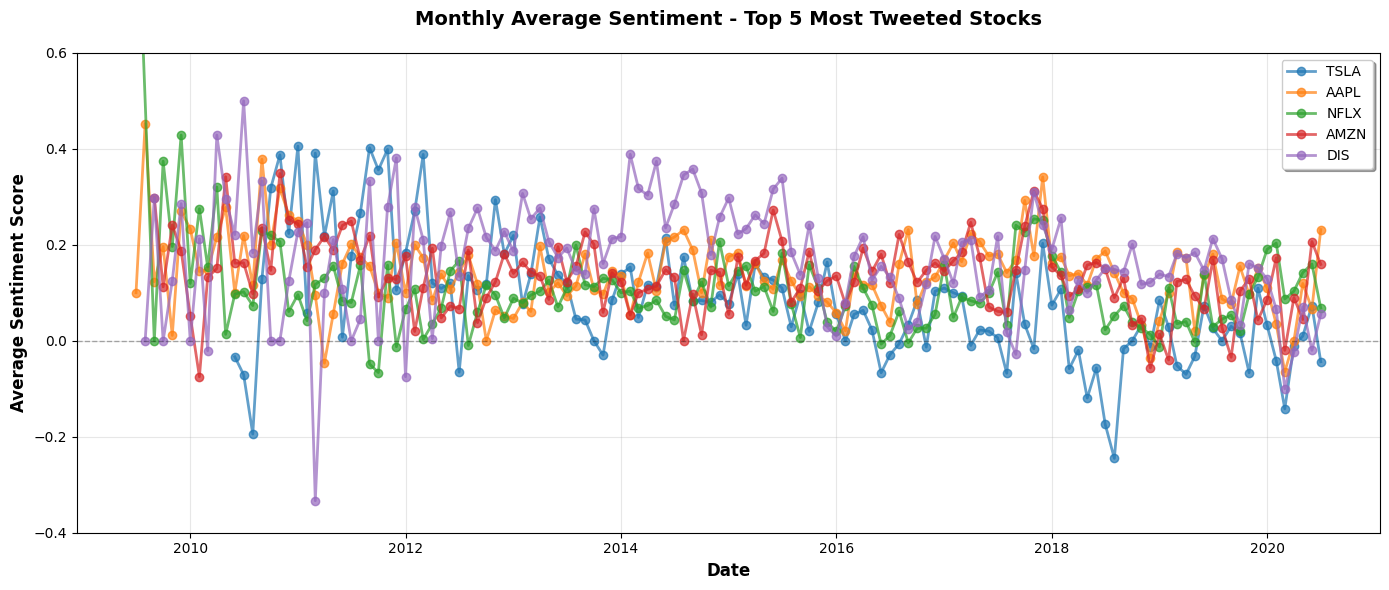

In [7]:
# Monthly Average Sentiment by Stock (Top 5 most tweeted stocks)
top_5_stocks = df_aggregated_sentiments.groupby('ticker')['n_tweets'].sum().nlargest(5).index
df_aggregated_sentiments['date'] = pd.to_datetime(
    df_aggregated_sentiments['date'], errors='coerce'
)

df_monthly = df_aggregated_sentiments[df_aggregated_sentiments['ticker'].isin(top_5_stocks)].copy()
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')
monthly_sentiment = df_monthly.groupby(['ticker', 'year_month'])['sent_index'].mean().reset_index()
monthly_sentiment['year_month'] = monthly_sentiment['year_month'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in top_5_stocks:
    ticker_data = monthly_sentiment[monthly_sentiment['ticker'] == ticker]
    ax.plot(ticker_data['year_month'], ticker_data['sent_index'],
            marker='o', linewidth=2, label=ticker, alpha=0.7)

ax.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Sentiment Score', fontsize=12, fontweight='bold')
ax.set_title('Monthly Average Sentiment - Top 5 Most Tweeted Stocks',
             fontsize=14, fontweight='bold', pad=20)

ax.set_ylim(-0.4, 0.6)  # <<< limit y-axis between -0.4 and 0.6

ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Monthly tweet sentiment for the five most-tweeted stocks hovers slightly above neutral, with modest cross-sectional differences. Most months sit between −0.1 and +0.3, indicating a generally mild positive tone. TSLA is the most volatile, with several negative runs (notably ~2011, 2017–2018, and pockets in 2020). DIS and AMZN tend to track a bit higher on average, while AAPL and NFLX cluster near the group mean. Peaks above 0.35 and dips below −0.2 are infrequent, and all series mean-revert toward the 0 (neutral) baseline.

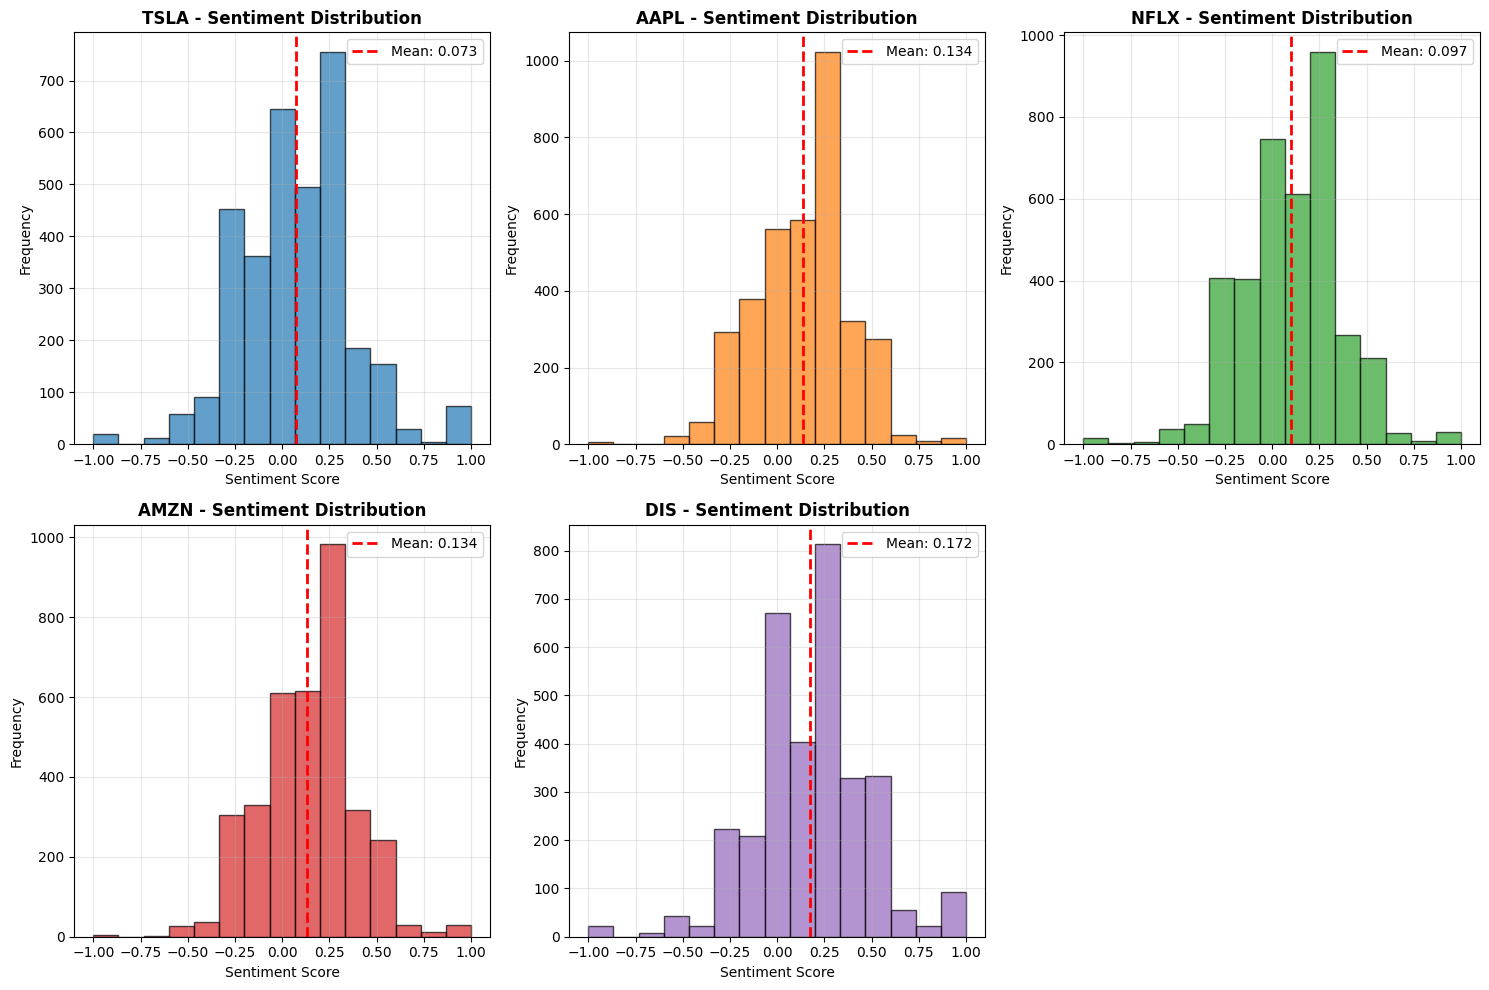

In [8]:
# Sentiment Distribution by Stock
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, ticker in enumerate(top_5_stocks):
    ticker_data = df_aggregated_sentiments[df_aggregated_sentiments['ticker'] == ticker]
    axes[idx].hist(ticker_data['sent_index'], bins= 15, alpha=0.7, 
                   color=f'C{idx}', edgecolor='black')
    axes[idx].axvline(x=ticker_data['sent_index'].mean(), 
                      color='red', linestyle='--', linewidth=2, 
                      label=f'Mean: {ticker_data["sent_index"].mean():.3f}')
    axes[idx].set_xlabel('Sentiment Score', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'{ticker} - Sentiment Distribution', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplot
if len(top_5_stocks) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()


Sentiment distributions for the five most‐tweeted stocks are centered slightly above zero, indicating generally mild positive tone. The dashed vertical line marks the average daily sentiment for each name: DIS is the most positive (~+0.17), AAPL and AMZN cluster around +0.13, NFLX around +0.10, and TSLA is the least positive (~+0.07). Most mass sits between −0.3 and +0.4. TSLA shows the widest spread and a heavier negative tail—consistent with more polarized chatter—while DIS is skewed positive with fewer negative days. Extreme values (near ±1) are rare.

#### **Media Attention Measure** pt.1

We start with Media Attention Score incorporating only the log-transformed number of tweets and the sentiment index mapped to [0,1].

$$
Media\_Attention\_Score = \log(1 + n\_tweets) \times (sent\_index + 1)/2
$$

**Logarithm transformation** controls for diminishing marginal effect of tweet volume, while smoothing the dynamics. 

**Normalized sentiment index** maps this score from [-1,1] --> [0,1] where 0.5 is now neutral.

In [9]:
df_aggregated_sentiments["Media_Attention_Score"] = (
    np.log(1 + df_aggregated_sentiments["n_tweets"]) * (df_aggregated_sentiments["sent_index"] + 1)/2
)

In [10]:
df_aggregated_sentiments.head()

,ticker,date,n_tweets,sent_index,Media_Attention_Score
0,AAPL,2009-07-10,1,0.0,0.346574
1,AAPL,2009-07-13,3,0.0,0.693147
2,AAPL,2009-07-29,1,1.0,0.693147
3,AAPL,2009-07-30,1,0.0,0.346574
4,AAPL,2009-07-31,2,-0.5,0.274653


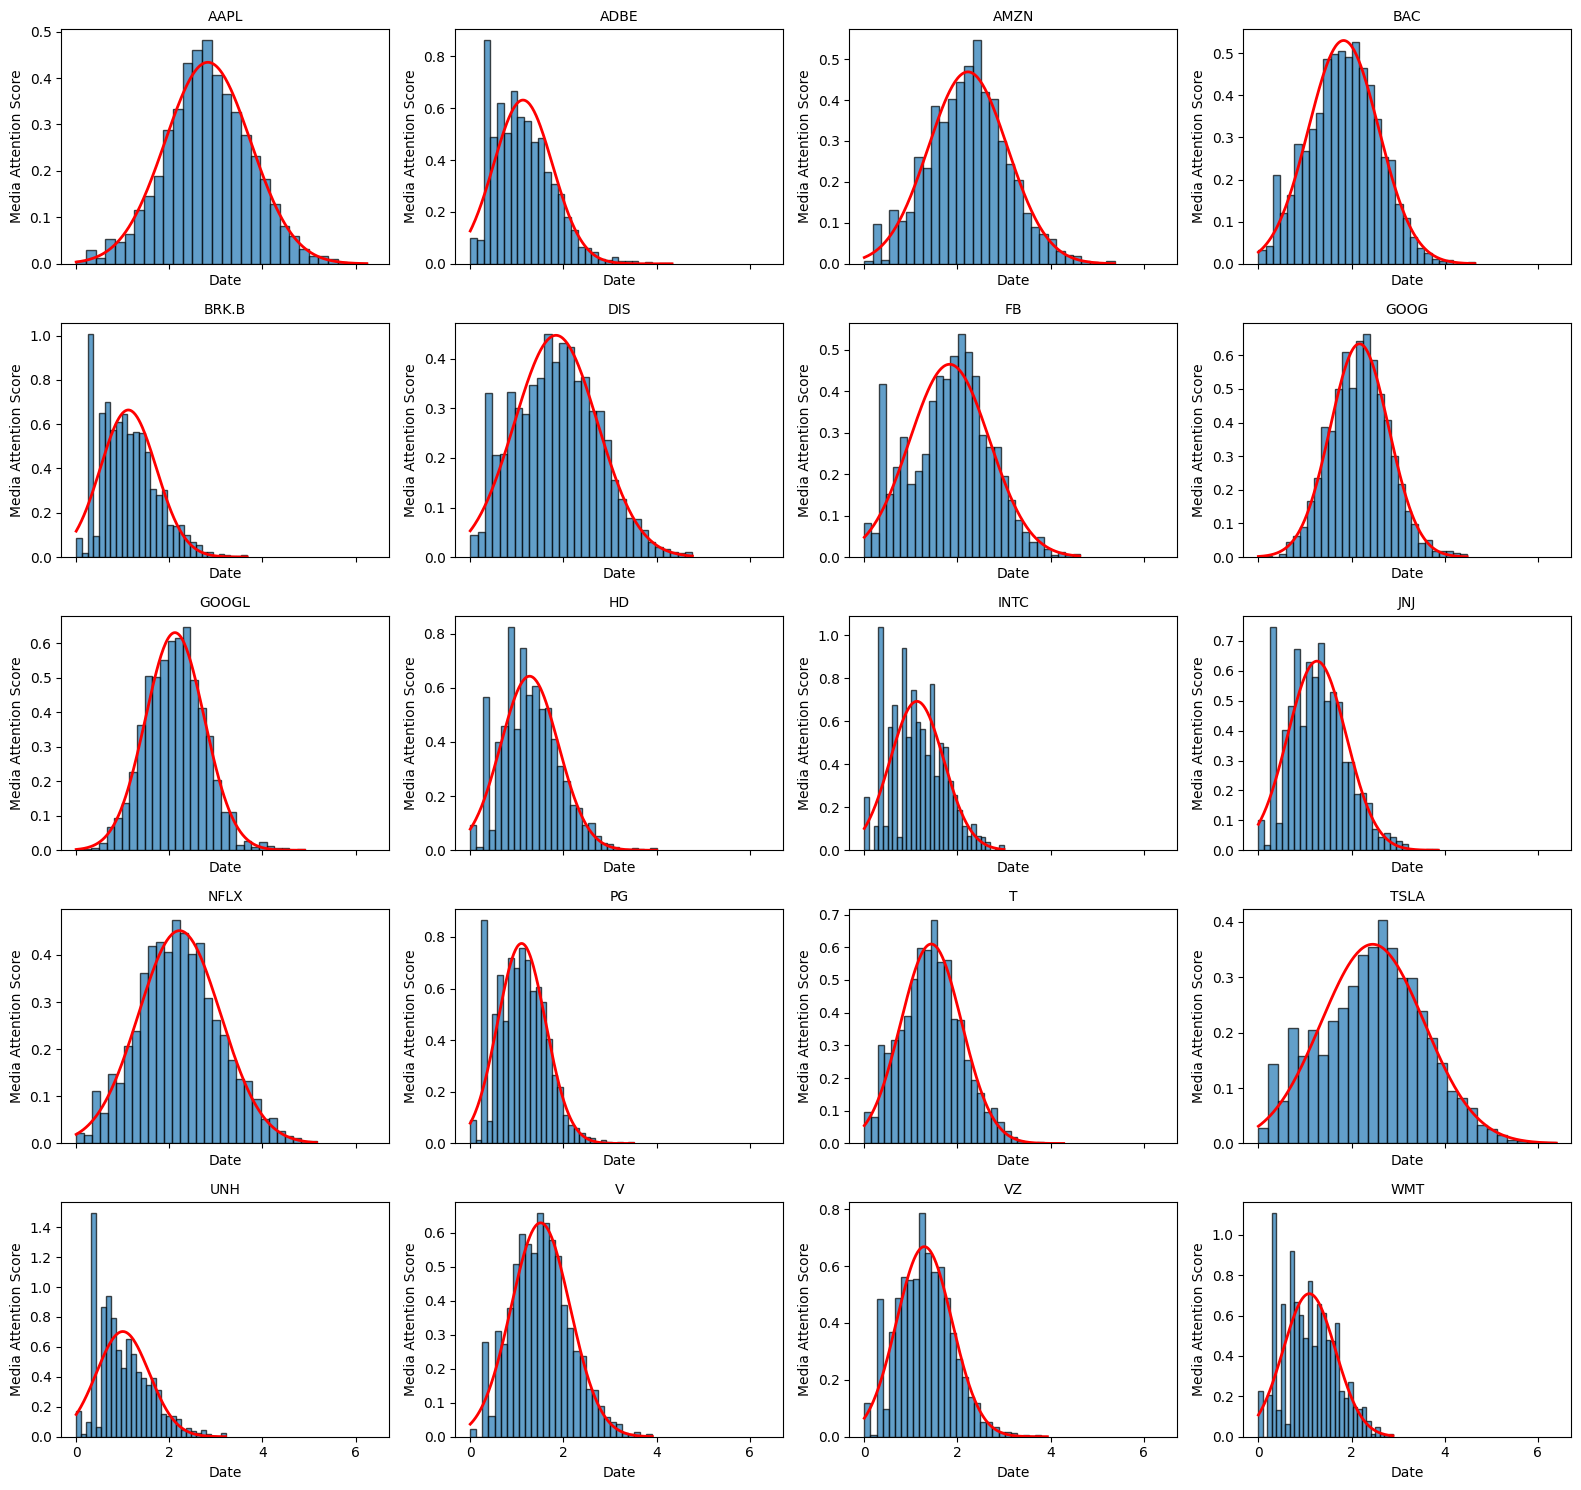

In [11]:
tickers = df_aggregated_sentiments["ticker"].unique()

# Grid size for subplots
n_cols = 4
n_rows = int(np.ceil(len(tickers) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows), sharex=True, sharey=False)
axes = axes.flatten()

for i, tkr in enumerate(sorted(tickers)):
    sub = df_aggregated_sentiments[df_aggregated_sentiments["ticker"] == tkr].sort_values("date")
    ax = axes[i]
    
    ax.hist(sub["Media_Attention_Score"], bins=30, alpha=0.7, edgecolor="black", density=True)
    
    # Fitting normal distribution
    data = sub["Media_Attention_Score"]
    mu, sigma = np.mean(data), np.std(data)
    x = np.linspace(data.min(), data.max(), 200)
    pdf = norm.pdf(x, mu, sigma)

    axes[i].plot(x, pdf, "r-", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
    ax.set_title(tkr, fontsize=10)
    ax.set_xlabel("Date")
    ax.set_ylabel("Media Attention Score")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Many stocks show **heavy right skewness** - most days have lower attention, but there are occasional spikes.
- Some stocks such as **AAPL, AMZN, NFLX, TSLA, GOOG and BAC** have distributions that look **more symmetric and bell-shaped**, though still slightly skewed.
- Tech companies such as **AAPL, AMZN, NFLX and TSLA** show **higher attention scores**.

#### **Media attention Measure** pt.2

We'll now move to a **more complex and sophisticated scoring** by accounting for the performance of other stocks and the one of the stock itself in the 60 days window.


**(1) Volume Transform**
$$
v_{i,t} = \log(1 + n\_tweets_{i,t})
$$

**(2) Cross-Sectional Percentile (per day)**
$$
CS_{i,t} = \mathrm{PercentileRank}(v_{i,t} \mid \text{date} = t), \quad CS_{i,t} \in [0, 1]
$$

**(3) Rolling Z-Score (within ticker)**
$$
\mu_{i,t} = \mathrm{mean}(v_{i, t-59:t}), \quad \sigma_{i,t} = \mathrm{std}(v_{i, t-59:t})
$$

$$
z_{i,t} = \frac{v_{i,t} - \mu_{i,t}}{\sigma_{i,t}}
$$

Clip and rescale to [0, 1]:
$$
z\_{{clip01},i,t} = \frac{\mathrm{clip}(z_{i,t}, -3, 3) + 3}{6}
$$

**(4) Media Attention Score \( g \)**
$$
g_{i,t} = 100 \times \left(0.6 \times CS_{i,t} + 0.4 \times z\_{{clip01},i,t}\right)
$$

$$
g_{i,t} \in [0, 100]
$$

**(5) Sentiment-Aware Media Score \( g_s \)**
$$
g\_s_{i,t} = g_{i,t} \times \text{sent\_index}_{i,t}
$$

$$
g\_s_{i,t} \in [-100, 100]
$$

In [151]:
# --------- Daily level: build g and g_s ----------
df = df_aggregated_sentiments.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"])

# (1) volume transform
df["v"] = np.log1p(df["n_tweets"])

# (2) cross-sectional percentile per day (0..1)
df["CS"] = df.groupby("date")["v"].rank(pct=True)

# (3) rolling z-score within ticker, then scale to 0..1
roll = df.groupby("ticker")["v"].rolling(60, min_periods=20)
mu = roll.mean().reset_index(level=0, drop=True)
sd = roll.std(ddof=0).reset_index(level=0, drop=True)
z = (df["v"] - mu) / sd
z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)      # handle zero-variance windows
df["z_clip01"] = ((z.clip(-3, 3) + 3) / 6.0)              # map [-3,3] to [0,1]

# (4) Media Attention Score g: 0..100
df["g"] = 100 * (0.6*df["CS"] + 0.4*df["z_clip01"])

# (5) Sentiment-aware media score g_s (keeps the sign from sent_index)
#     g_s is in roughly [-100, 100] before any aggregation.
df["g_s"] = df["g"] * df["sent_index"]

# Optional smoothing at daily level (nice for daily charts)
df["g_7d"]   = df.groupby("ticker")["g"]  .transform(lambda s: s.rolling(7, min_periods=3).mean())
df["g_s_7d"] = df.groupby("ticker")["g_s"].transform(lambda s: s.rolling(7, min_periods=3).mean())


In [152]:
# --------- Monthly aggregates (for clean plotting) ----------
monthly = (
    df.set_index("date")
      .groupby("ticker")
      .resample("M")
      .agg(
          n_tweets=("n_tweets", "sum"),
          g=("g", "mean"),           # monthly mean of g (0..100)
          g_med=("g", "median"),
          g_s=("g_s", "mean"),       # monthly mean of g_s (can be negative)
          sent=("sent_index", "mean")
      )
      .reset_index()
)

# pick top 5 tickers by total tweet volume over the whole sample (adjust if you prefer another rule)
top5 = (monthly.groupby("ticker")["n_tweets"].sum().nlargest(5).index.tolist())

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_93305/1334630628.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


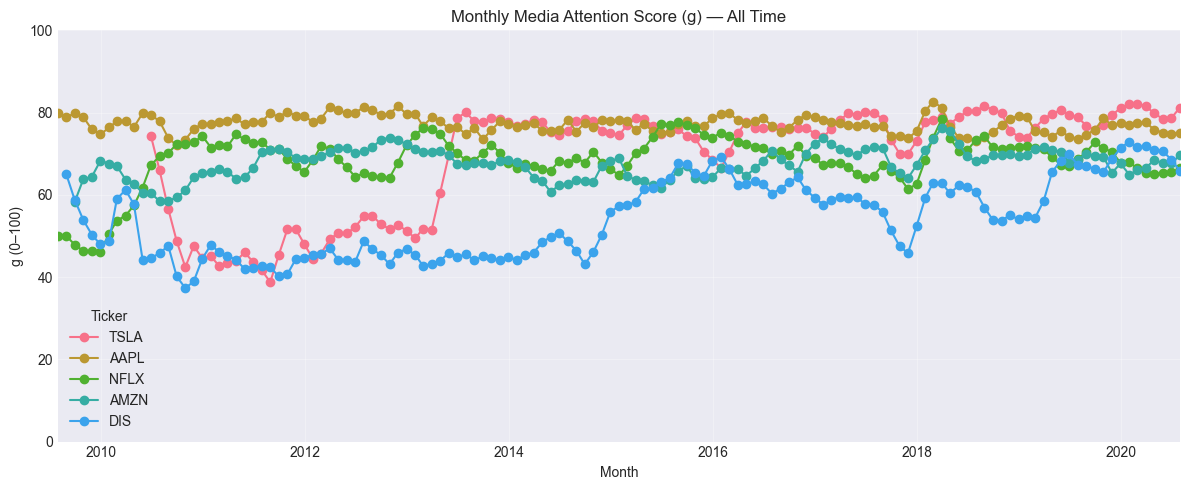

In [153]:
# ---------- Monthly g (0..100) ----------
fig, ax = plt.subplots(figsize=(12, 5))
for t in top5:
    s = (monthly[monthly["ticker"] == t]
         .set_index("date")["g"]
         .sort_index()
         .rolling(3, min_periods=1).mean())  # light smoothing
    ax.plot(s.index, s.values, marker='o', linewidth=1.5, label=t)

ax.set_ylim(0, 100)
ax.set_xlim(monthly["date"].min(), monthly["date"].max())
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator())

ax.set_title("Monthly Media Attention Score (g) — All Time")
ax.set_xlabel("Month")
ax.set_ylabel("g (0–100)")
ax.legend(title="Ticker")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



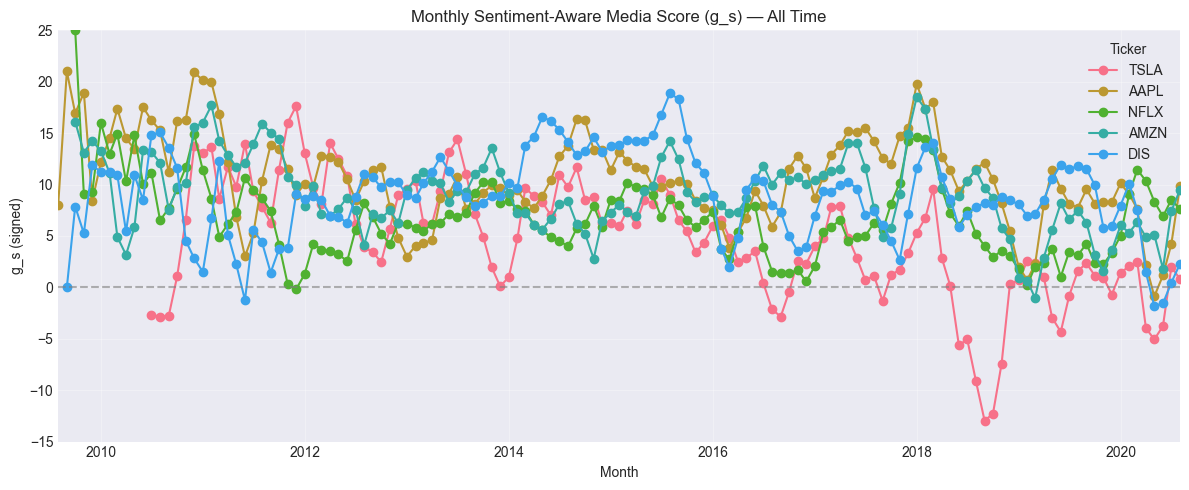

In [154]:
# ---------- Monthly g_s (sentiment-aware; can be negative) ----------
fig, ax = plt.subplots(figsize=(12, 5))
for t in top5:
    s = (monthly[monthly["ticker"] == t]
         .set_index("date")["g_s"]
         .sort_index()
         .rolling(3, min_periods=1).mean())
    ax.plot(s.index, s.values, marker='o', linewidth=1.5, label=t)

# symmetric y-lims around zero for readability (adjust if needed)
ymax = np.nanpercentile(np.abs(monthly["g_s"]), 98)
ax.set_ylim(-15, 25)

ax.set_xlim(monthly["date"].min(), monthly["date"].max())
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator())

ax.axhline(0, linestyle='--', color='gray', alpha=0.6)
ax.set_title("Monthly Sentiment-Aware Media Score (g_s) — All Time")
ax.set_xlabel("Month")
ax.set_ylabel("g_s (signed)")
ax.legend(title="Ticker")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Web-scraping - Yahoo Finance data

In [155]:
tickers = df_aggregated_sentiments['ticker'].unique()
tickers = list(tickers) + ["^GSPC"] # S&P 500
tickers = [s.replace('.','-') for s in tickers]
print(tickers)

['AAPL', 'ADBE', 'AMZN', 'BAC', 'BRK-B', 'DIS', 'FB', 'GOOG', 'GOOGL', 'HD', 'INTC', 'JNJ', 'NFLX', 'PG', 'T', 'TSLA', 'UNH', 'V', 'VZ', 'WMT', '^GSPC']


In [156]:
start = datetime.datetime(2009, 7, 9)
data = yf.download(tickers, start=start, end=None)

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_93305/4136676933.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=None)
[*********************100%***********************]  21 of 21 completed


In [157]:
data.head()

Price          Close                                                          \
Ticker          AAPL       ADBE    AMZN        BAC      BRK-B        DIS  FB   
Date                                                                           
2009-07-09  4.093543  27.420000  3.9050   9.320660  55.419998  19.082455 NaN   
2009-07-10  4.158388  27.580000  3.8815   9.250582  54.900002  18.980812 NaN   
2009-07-13  4.273064  28.370001  4.0735  10.114902  56.560001  19.226437 NaN   
2009-07-14  4.270962  28.299999  4.0975  10.052607  57.400002  19.573698 NaN   
2009-07-15  4.409355  29.850000  4.2275  10.449732  58.799999  20.395269 NaN   

Price                                        ...    Volume            \
Ticker           GOOG      GOOGL         HD  ...       JNJ      NFLX   
Date                                         ...                       
2009-07-09  10.151965  10.199671  15.327246  ...  11324800  12084100   
2009-07-10  10.251161  10.299334  15.219118  ...  13661800   5254900   
2009-07-13  10.496062  10.545386  15.617841  ...  13564900  29690500   
2009-07-14  10.505711  10.555079  16.003044  ...  20433700  13967800   
2009-07-15  10.839168  10.890105  16.273375  ...  12986200   9424800   

Price                                                                        \
Ticker            PG         T TSLA       UNH         V        VZ       WMT   
Date                                                                          
2009-07-09  11648100  33712747  NaN   8967800  26616400  15224190  45369600   
2009-07-10   9267400  28892460  NaN   5621200  16654800  13454364  47913300   
2009-07-13  12289100  34067447  NaN   5801600  30640000  13777003  48102900   
2009-07-14  12817300  35882783  NaN   9708400  13291200  13648737  40399200   
2009-07-15  15161300  34004424  NaN  12532300  36492400  19160263  56225100   

Price                   
Ticker           ^GSPC  
Date                    
2009-07-09  4347170000  
2009-07-10  3912080000  
2009-07-13  4499440000  
2009-07-14  4149030000  
2009-07-15  5238830000  

[5 rows x 105 columns]

In [158]:
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,ADBE,AMZN,BAC,BRK-B,DIS,FB,GOOG,GOOGL,HD,...,JNJ,NFLX,PG,T,TSLA,UNH,V,VZ,WMT,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2009-07-09,4.093543,27.420000,3.9050,9.320660,55.419998,19.082455,NaN,10.151965,10.199671,15.327246,...,35.086262,5.707143,32.660568,5.528629,NaN,19.587217,13.456742,11.847854,11.393738,882.679993
2009-07-10,4.158388,27.580000,3.8815,9.250582,54.900002,18.980812,NaN,10.251161,10.299334,15.219118,...,35.234798,5.724286,32.542171,5.542817,NaN,19.375164,13.327608,11.839575,11.272885,879.130005
2009-07-13,4.273064,28.370001,4.0735,10.114902,56.560001,19.226437,NaN,10.496062,10.545386,15.617841,...,35.723732,6.027143,33.015781,5.620850,NaN,19.642191,13.436705,12.017466,11.334497,901.049988
2009-07-14,4.270962,28.299999,4.0975,10.052607,57.400002,19.573698,NaN,10.505711,10.555079,16.003044,...,36.039394,6.185714,33.364758,5.545182,NaN,19.453701,13.423346,11.976091,11.405588,905.840027
2009-07-15,4.409355,29.850000,4.2275,10.449732,58.799999,20.395269,NaN,10.839168,10.890105,16.273375,...,36.491180,6.344286,34.056484,5.668147,NaN,19.563646,13.948791,12.137424,11.505115,932.679993


In [159]:
returns = close_prices.pct_change()
returns = returns.iloc[1:]
returns.head()

Ticker,AAPL,ADBE,AMZN,BAC,BRK-B,DIS,FB,GOOG,GOOGL,HD,...,JNJ,NFLX,PG,T,TSLA,UNH,V,VZ,WMT,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2009-07-10,0.015841,0.005835,-0.006018,-0.007519,-0.009383,-0.005326,NaN,0.009771,0.009771,-0.007055,...,0.004233,0.003004,-0.003625,0.002566,NaN,-0.010826,-0.009596,-0.000699,-0.010607,-0.004022
2009-07-13,0.027577,0.028644,0.049465,0.093434,0.030237,0.012941,NaN,0.023890,0.023890,0.026199,...,0.013876,0.052907,0.014554,0.014078,NaN,0.013782,0.008186,0.015025,0.005466,0.024934
2009-07-14,-0.000492,-0.002467,0.005892,-0.006159,0.014851,0.018062,NaN,0.000919,0.000919,0.024664,...,0.008836,0.026309,0.010570,-0.013462,NaN,-0.009596,-0.000994,-0.003443,0.006272,0.005316
2009-07-15,0.032403,0.054770,0.031727,0.039505,0.024390,0.041973,NaN,0.031741,0.031741,0.016892,...,0.012536,0.025635,0.020732,0.022175,NaN,0.005652,0.039144,0.013471,0.008726,0.029630
2009-07-16,0.004357,0.034171,0.018451,-0.018629,-0.005782,0.029485,NaN,0.010110,0.010110,0.013289,...,0.004919,-0.006305,0.010247,-0.010847,NaN,0.013649,0.028093,0.005454,-0.000823,0.008642


In [160]:
returns_long = returns.stack().reset_index()
returns_long.columns = ["date", "ticker", "return"]
returns_long.head()

,date,ticker,return
0,2009-07-10,AAPL,0.015841
1,2009-07-10,ADBE,0.005835
2,2009-07-10,AMZN,-0.006018
3,2009-07-10,BAC,-0.007519
4,2009-07-10,BRK-B,-0.009383


In [161]:
returns_long["date"] = pd.to_datetime(returns_long["date"])
df_aggregated_sentiments["date"] = pd.to_datetime(df_aggregated_sentiments["date"])

### Merging returns and aggregated sentiments datasets pt.1
For the plots below, the first Media Attention Score is used:

In [162]:
merged_df = pd.merge(
    df_aggregated_sentiments,
    returns_long,
    on=["ticker", "date"],
    how="inner"
)

merged_df = merged_df.sort_values(by="date", ascending=True).reset_index(drop=True)
merged_df.head()

,ticker,date,n_tweets,sent_index,Media_Attention_Score,return
0,AAPL,2009-07-10,1,0.0,0.346574,0.015841
1,AAPL,2009-07-13,3,0.0,0.693147,0.027577
2,BAC,2009-07-13,1,1.0,0.693147,0.093434
3,NFLX,2009-07-13,1,1.0,0.693147,0.052907
4,AAPL,2009-07-29,1,1.0,0.693147,0.000187


#### • Do you see a correlation between media attention g and stock returns?

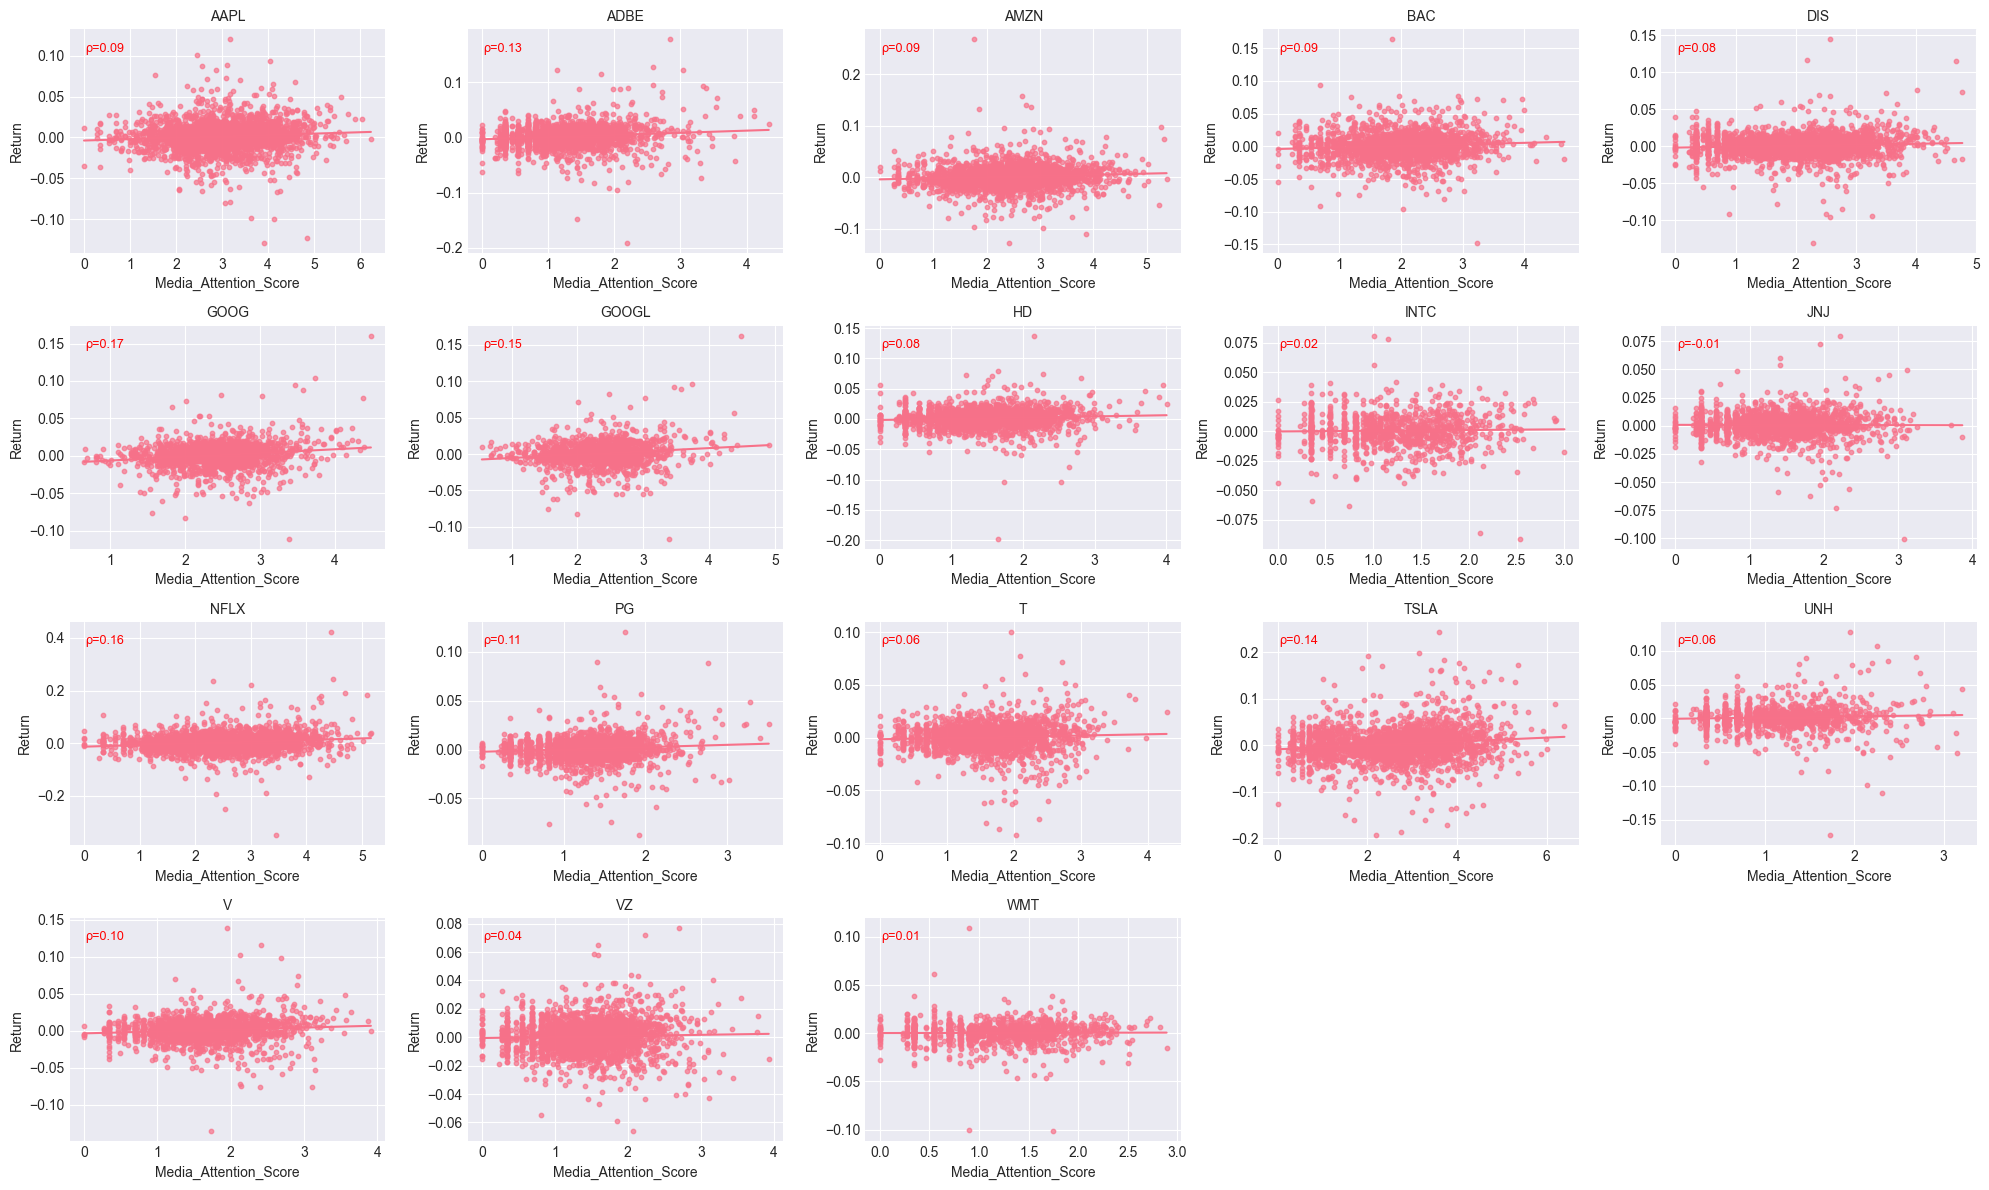

In [163]:
tickers = merged_df["ticker"].dropna().unique()
n_tickers = len(tickers)

# grid size
n_cols = int(np.ceil(np.sqrt(n_tickers)))
n_rows = int(np.ceil(n_tickers / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=False, sharey=False)
axes = axes.flatten()

for i, tkr in enumerate(sorted(tickers)):
    sub = merged_df[merged_df["ticker"] == tkr]
    ax = axes[i]
    
    ax.scatter(sub["Media_Attention_Score"], sub["return"], s=10, alpha=0.7)
    
    # regression line
    if len(sub) > 1:
        try:
            m, b = np.polyfit(sub["Media_Attention_Score"], sub["return"], 1)
            x_line = np.linspace(sub["Media_Attention_Score"].min(), sub["Media_Attention_Score"].max(), 100)
            ax.plot(x_line, m*x_line + b, linewidth=1.5)
        except:
            pass

    ax.set_title(tkr, fontsize=10)
    ax.set_xlabel("Media_Attention_Score")
    ax.set_ylabel("Return")

    # Correlation
    if len(sub) > 1:
        corr = sub["Media_Attention_Score"].corr(sub["return"])
        ax.text(0.05, 0.9, f"ρ={corr:.2f}", transform=ax.transAxes,
                fontsize=9, color="red", ha="left")

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- For most tickers, the scatter is very “cloud-like” with **no strong slope**. 
- Almost all correlations are positive, although weak. This could mean that **higher attention very slightly coincides with positive returns** — but the effect is economically small.
- On **high-attention days**, the **spread of returns widens**, but the correlation with the mean return remains weak.

### Merging returns and aggregated sentiments datasets pt. 2

From this part, we'll **continue using the second Media Attention score**, accounting for other stocks and the stock's performance itself in the 60 days window:

In [ ]:
# 1) Start from your aggregated file
df = df_aggregated_sentiments.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker","date"])

# 2)
if "g" not in df.columns or "g_s" not in df.columns:
    # (a) volume transform
    df["v"] = np.log1p(df["n_tweets"])
    # (b) cross-sectional percentile per day (0..1)
    df["CS"] = df.groupby("date")["v"].rank(pct=True)
    # (c) rolling z within ticker, scaled to [0,1]
    roll = df.groupby("ticker")["v"].rolling(60, min_periods=20)
    mu = roll.mean().reset_index(level=0, drop=True)
    sd = roll.std(ddof=0).reset_index(level=0, drop=True)
    z = (df["v"] - mu) / sd
    z = z.replace([np.inf,-np.inf], np.nan).fillna(0.0)
    df["z_clip01"] = ((z.clip(-3,3) + 3) / 6.0)

    # (d) media attention score (0..100)
    df["g"] = 100 * (0.6*df["CS"] + 0.4*df["z_clip01"])
    # (e) sentiment-aware (signed)
    df["g_s"] = df["g"] * df["sent_index"]

# 3) Merge with returns
merged_df = pd.merge(
    df[["ticker","date","g","g_s"]],
    returns_long,                       # columns: ticker, date, return
    on=["ticker","date"],
    how="inner"
).dropna(subset=["return"])

# winsorize returns to reduce outlier leverage in the fit
q1, q99 = merged_df["return"].quantile([0.01, 0.99])
merged_df["return_w"] = merged_df["return"].clip(q1, q99)

merged_df = merged_df.sort_values("date").reset_index(drop=True)


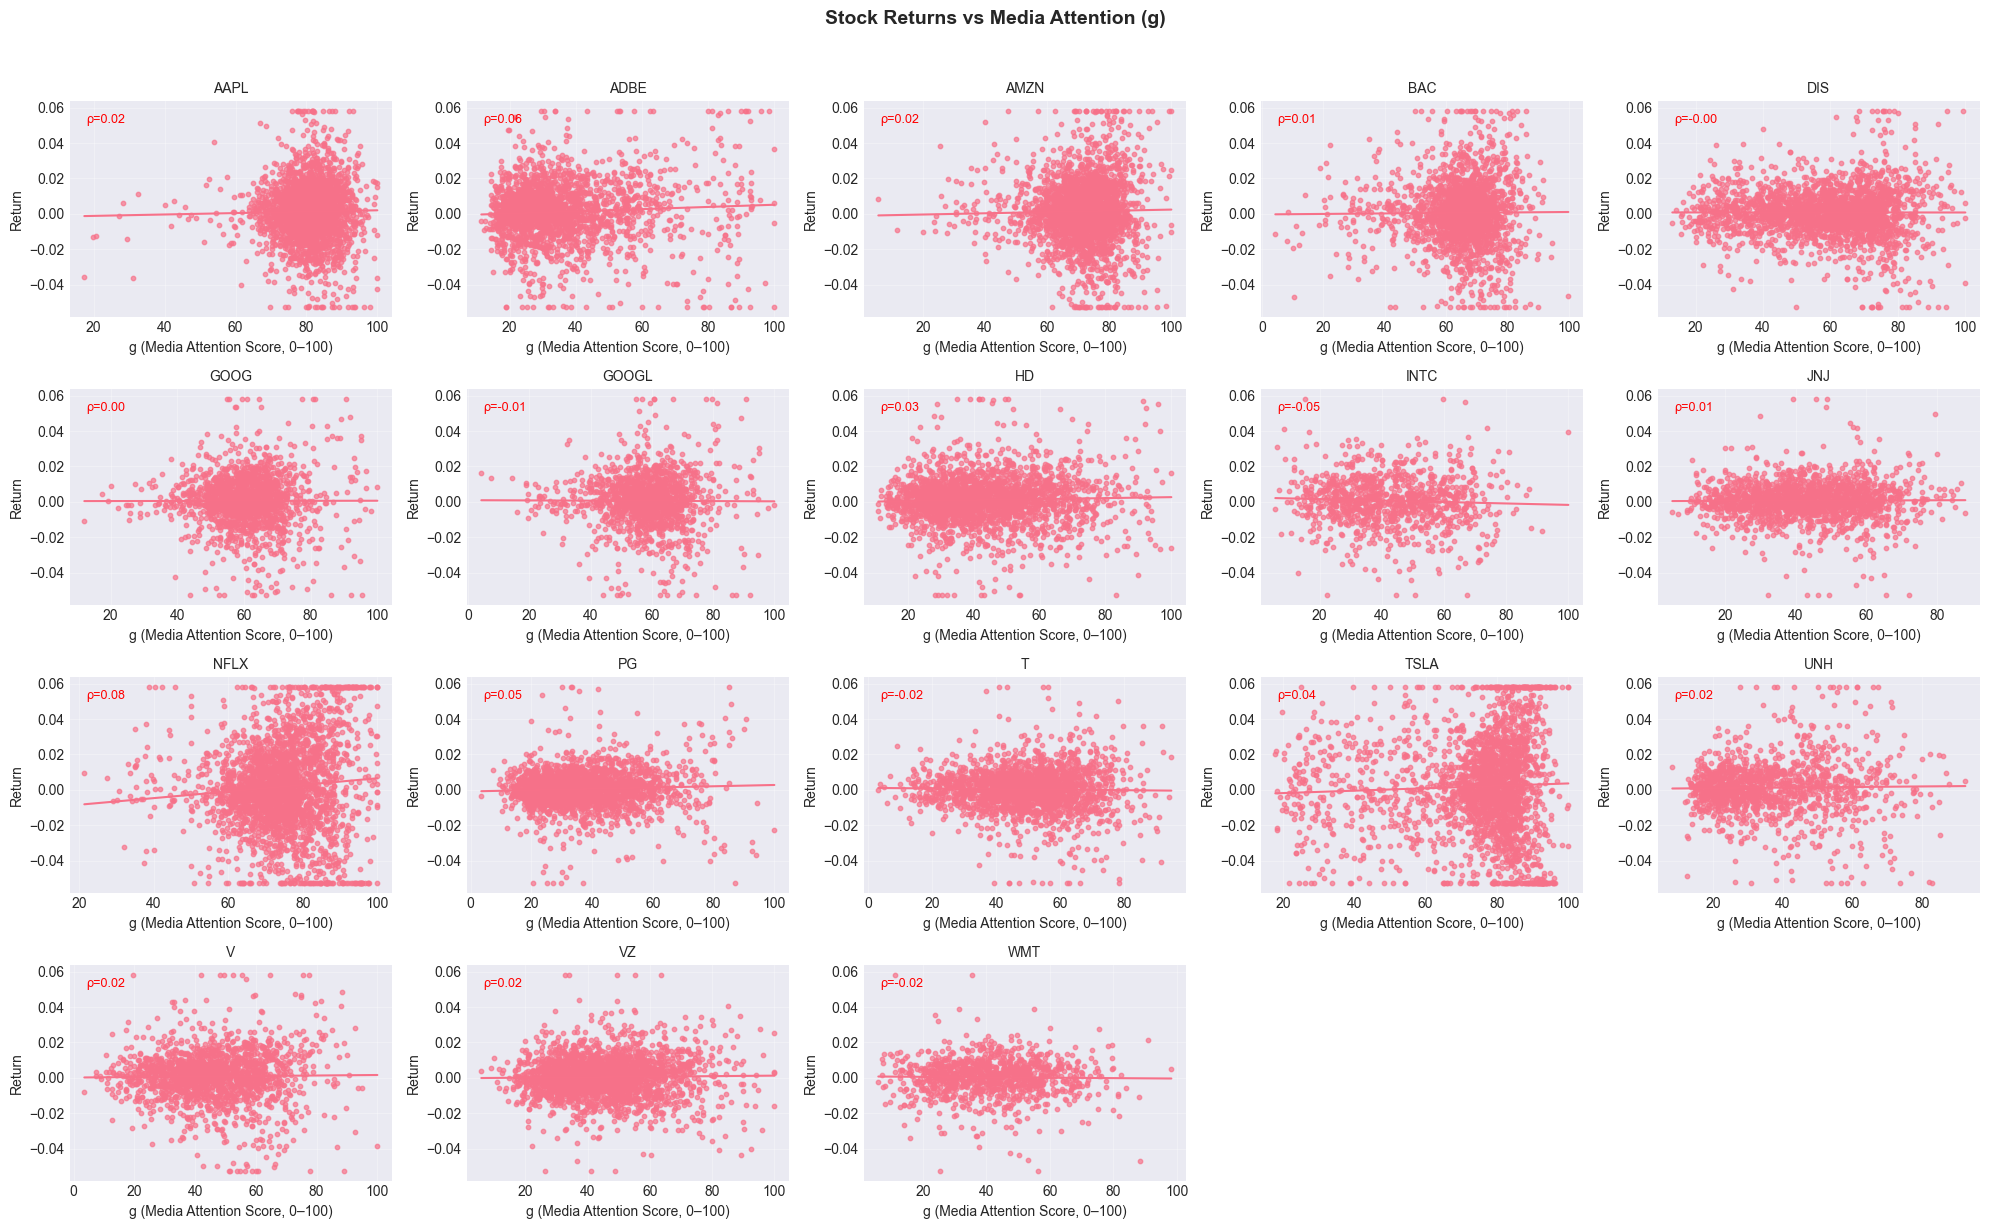

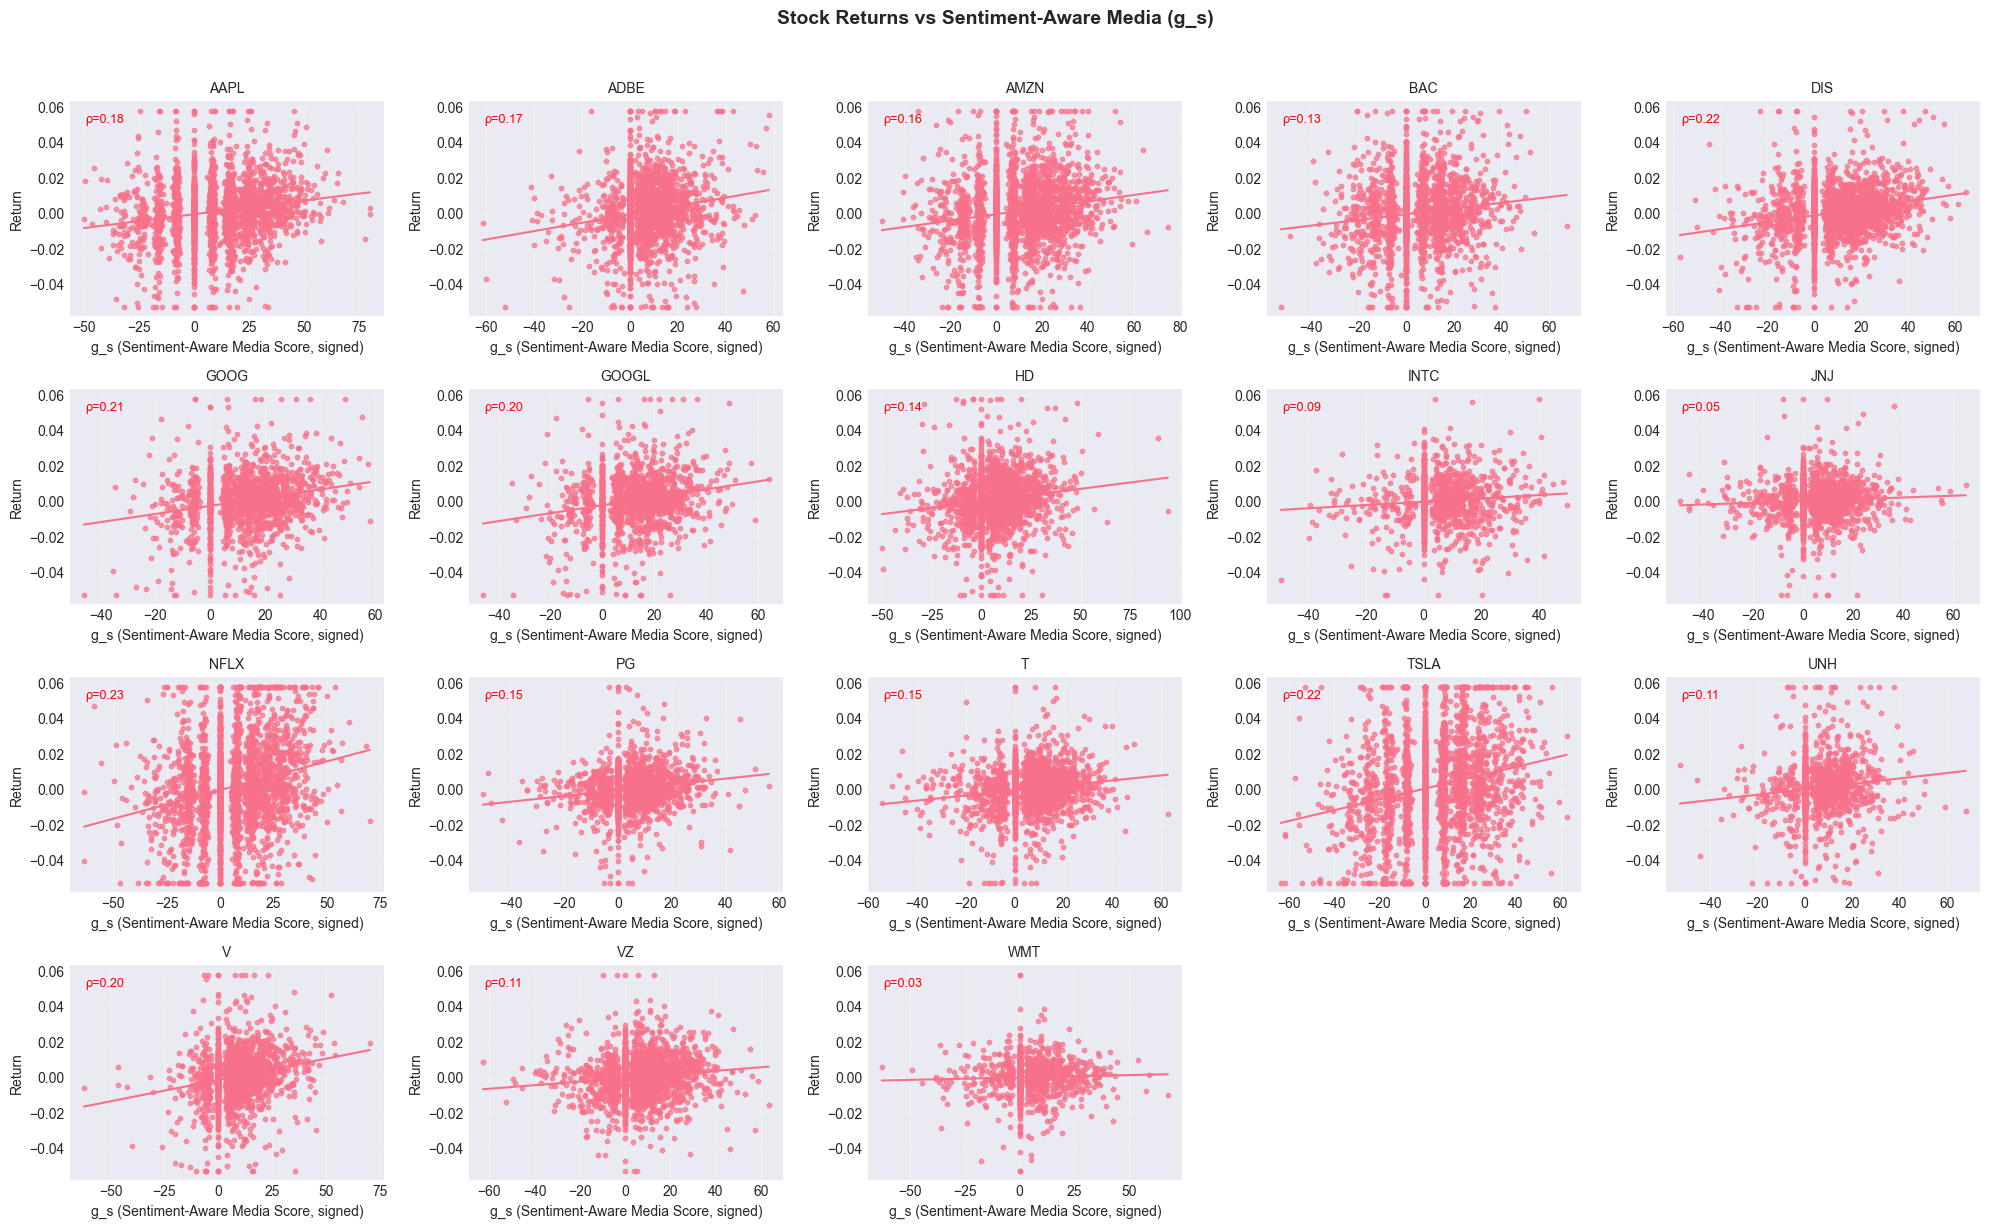

In [165]:
def plot_scatter_grid(df_in, xcol, ycol, xlab, title):
    tickers = sorted(df_in["ticker"].dropna().unique())
    n = len(tickers)
    n_cols = int(np.ceil(np.sqrt(n)))
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), sharex=False, sharey=False)
    axes = np.array(axes).reshape(-1)
    for i, tkr in enumerate(tickers):
        ax = axes[i]
        sub = df_in[df_in["ticker"] == tkr].dropna(subset=[xcol, ycol])
        ax.scatter(sub[xcol], sub[ycol], s=10, alpha=0.7)

        # OLS line (robust enough for quick view)
        if len(sub) > 1 and sub[xcol].std() > 0:
            m, b = np.polyfit(sub[xcol], sub[ycol], 1)
            xs = np.linspace(sub[xcol].min(), sub[xcol].max(), 100)
            ax.plot(xs, m*xs + b, linewidth=1.5)

        # Pearson correlation
        rho = sub[xcol].corr(sub[ycol]) if len(sub) > 1 else np.nan
        ax.text(0.05, 0.9, f"ρ={rho:.2f}", transform=ax.transAxes, fontsize=9, color="red", ha="left")

        ax.set_title(tkr, fontsize=10)
        ax.set_xlabel(xlab); ax.set_ylabel("Return")
        ax.grid(True, alpha=0.3)

    # remove empties
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, y=1.02, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# A) Returns vs g (0–100)
plot_scatter_grid(
    merged_df.rename(columns={"return_w":"ret"}).assign(ret=merged_df["return_w"]),
    xcol="g", ycol="ret", xlab="g (Media Attention Score, 0–100)",
    title="Stock Returns vs Media Attention (g)"
)

# B) Returns vs g_s (signed)
plot_scatter_grid(
    merged_df.rename(columns={"return_w":"ret"}).assign(ret=merged_df["return_w"]),
    xcol="g_s", ycol="ret", xlab="g_s (Sentiment-Aware Media Score, signed)",
    title="Stock Returns vs Sentiment-Aware Media (g_s)"
)

#### • Do you see a correlation between media attention g and stock returns?

Little or no correlation can be observed. Most panels look like pink “clouds” with near-flat fit lines and tiny ρ’s (≈0.00–0.08).

**Interpretation:** attention alone (g) co-moves very weakly with the day’s return; high attention mostly increases dispersion of returns, not the mean.

#### • If yes, could Twitter attention is likely to be a good factor?

As a standalone factor, g doesn’t look promising. The **same-day relation is economically small** and likely **driven by simultaneity (price moves → tweets)**, so it’s not compelling for prediction.

The **sentiment-aware score (g_s) is a bit better**: correlations are consistently larger (often ~0.10–0.25) and slopes tilt in the expected direction—when attention is positive, returns tend to be slightly higher. But it’s still modest and noisy.

We should test its predictive power. But we can see as well that the **method 2** media attention score has higher correlation with return. 

**We also tried to test the day before media attention score with today's return but it has an even lower correlation.**

### Create 10 portfolios based on your preferred measure of media attention

**Goal.** Evaluate how stock returns behave across levels of **sentiment-weighted media attention**. Let $g_s\in[0,100]$ be the media-attention score and $\text{sent\_index}\in[-1,1]$ be daily sentiment. Define
$$
g_s \;=\; g \times \text{sent\_index}.
$$

Procedure (daily, equal-weighted)

1. **Signal selection.**  
   Use $g_{s,i,t}$ for each stock $i$ on day $t$ as the cross-sectional sorting signal.

2. **Return to evaluate.**  
   With `USE_NEXT_DAY = False`, evaluate **same-day** returns:
   $$
   r^{\text{eval}}_{i,t} = r_{i,t}.
   $$

3. **Cross-section clean-up.**  
   Drop observations with missing $g_{s,i,t}$ or $r^{\text{eval}}_{i,t}$.  
   Skip “thin” dates with fewer than 10 available stocks.

4. **Daily decile assignment.**  
   Rank stocks by $g_{s,i,t}$ **within each date** and split into 10 equal groups
   $\mathcal{D}_1(t),\ldots,\mathcal{D}_{10}(t)$:
   $$
   \mathcal{D}_1(t)=\text{lowest } g_s,\quad \ldots,\quad \mathcal{D}_{10}(t)=\text{highest } g_s .
   $$

5. **Decile portfolio returns (equal-weighted).**  
   For each day $t$ and decile $d$,
   $$
   R_{d,t} \;=\; \frac{1}{|\mathcal{D}_d(t)|}\sum_{i\in \mathcal{D}_d(t)} r^{\text{eval}}_{i,t}.
   $$
   This yields a **daily time series** $\{R_{d,t}\}$ for $d=1,\ldots,10$.

6. **Long–short spread.**  
   Construct the high-minus-low series:
   $$
   R^{\text{LS}}_t \;=\; R_{10,t} - R_{1,t}.
   $$

7. **Summary statistics.**  
   Report time-series averages and an approximate $t$-statistic:
   $$
   \bar{R}_d=\frac{1}{T}\sum_{t=1}^{T} R_{d,t}, \qquad
   \bar{R}^{\text{LS}}=\frac{1}{T}\sum_{t=1}^{T} R^{\text{LS}}_t, \qquad
   t\text{-stat}=\frac{\bar{R}^{\text{LS}}}{\mathrm{sd}(R^{\text{LS}})/\sqrt{T}} .
   $$

In [229]:
# === CONFIG ===
SCORE_COL = "g_s"      # sort on signed attention
RET_COL   = "return"   # or "return_w"
USE_NEXT_DAY = False   # True => use r_{t+1}; False => same-day

dfp = merged_df.sort_values(["ticker","date"]).copy()
dfp["ret_eval"] = (dfp.groupby("ticker")[RET_COL].shift(-1) if USE_NEXT_DAY
                   else dfp[RET_COL])

# Keep rows with both score and evaluation return
base = dfp.dropna(subset=[SCORE_COL, "ret_eval"]).copy()

# (optional) skip thin days
min_names = 10
base = base[base.groupby("date")["ticker"].transform("nunique") >= min_names]

# Assign daily deciles 0..9 by cross-sectional rank
def _as_deciles(g):
    r = g[SCORE_COL].rank(method="first", pct=True)
    return np.minimum((r*10).astype(int), 9)

base["dec"] = base.groupby("date", group_keys=False).apply(_as_deciles)

# Equal-weight decile returns (time series)
dec_ts = (base.groupby(["date","dec"])["ret_eval"].mean()
               .unstack("dec")
               .rename(columns=lambda k: f"D{k+1}"))  # D1..D10

# --- summary in natural order D1..D10 ---
order = [f"D{i}" for i in range(1, 11)]
dec_means = dec_ts.mean().reindex(order)                      # <-- fix order
dec_std   = dec_ts.std(ddof=1).reindex(order)
dec_se    = dec_std / np.sqrt(len(dec_ts))

# Long–short
ls = dec_ts["D10"] - dec_ts["D1"]
ls_mean = ls.mean()
ls_se   = ls.std(ddof=1) / np.sqrt(len(ls))
print(dec_means.apply(lambda x: f"{x:.4%}"))
print(f"Long–short (D10−D1): {ls_mean:.4%} (SE {ls_se:.4%}, t≈{ls_mean/ls_se:.2f})")

dec
D1     -0.3153%
D2     -0.1962%
D3     -0.0599%
D4      0.0089%
D5      0.0987%
D6      0.0816%
D7      0.1120%
D8      0.1557%
D9      0.2892%
D10     0.4716%
dtype: object
Long–short (D10−D1): 0.7936% (SE 0.0508%, t≈15.63)


/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_93305/3859234707.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  base["dec"] = base.groupby("date", group_keys=False).apply(_as_deciles)


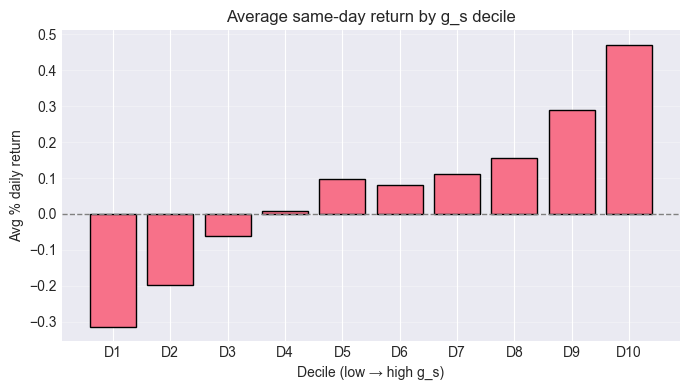

In [230]:
x = np.arange(10)
y = dec_means.values * 100
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(x, y, edgecolor="black")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"D{d+1}" for d in x])
ax.set_title(f"Average {'next-day' if USE_NEXT_DAY else 'same-day'} return by g_s decile")
ax.set_xlabel("Decile (low → high g_s)"); ax.set_ylabel("Avg % daily return")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

- The bars rise almost monotonically from **D1 ≈ −0.30%** to **D10 ≈ +0.47%**.  
  → On days when **sentiment-weighted attention** is **most negative/low** (low $g_s$), average returns are negative; when it is **most positive/high** (high $g_s$), average returns are positive.

- The implied same-day cross-sectional spread is roughly **D10 − D1 ≈ +0.8%** per day—large in magnitude, at least contemporaneously.

- Mid deciles show small positives (~0.05–0.15%), reinforcing a **smooth, increasing pattern** across $g_s$.

We can conclude that: 
- **Pure attention $g$ (volume only):** weak/near-zero relation (the earlier scatters looked like clouds).  
- **Sentiment-aware attention $g_s$:** there is a clear **same-day** positive association (higher $g_s$ ↔ higher return).

Twitter is likely to be a good factor:
- **Attention alone ($g$):** not convincing.  
- **Twitter attention with sentiment ($g_s$):** **promising as a signal**, but this chart is **same-day** and likely reflects *contemporaneous news* (tweets and prices react together). To claim a tradable “factor” we still need predictive, risk-adjusted evidence.


Next checks to make it factor-grade:

**Risk adjustment:** repeat on **FF-5–purged residuals** to show the spread isn’t just factor exposure.



### • Optional : same, but use FF-5 factors to purge returns from what a traditional model predicts, and plot media attention vs. erros

In [222]:
# ============================================================
# CONFIG
# ============================================================
FACTOR_FILE = "F-F_Research_Data_5_Factors_2x3_daily.csv"  # Ken French daily 5 factors
EVAL_NEXT_DAY = False     # False = **in-sample (same-day)** residuals; True = use next-day residuals
SAVE_RESIDUALS = True     # save residuals to CSV for reuse
RESIDUALS_OUT = "ff5_residuals_static.csv"
MIN_STOCKS_PER_DAY = 10   # skip very thin cross-sections
RET_COL = "return"        # use your raw daily return (or "return_w" if you want winsorized)


#### Download the Fama–French 5 factors (Mkt-RF, SMB, HML, RMW, CMA, and RF) from Ken French’s Data Library

In [223]:
## LOAD AND CLEAN

factors_df = pd.read_csv(FACTOR_FILE, skiprows=3)

# standardize names
factors_df = factors_df.rename(columns={"Unnamed: 0": "date", "Mkt-RF": "MKT_RF"})
ff_cols = ["MKT_RF", "SMB", "HML", "RMW", "CMA", "RF"]

# numeric + drop footer lines
for c in ff_cols:
    factors_df[c] = pd.to_numeric(factors_df[c], errors="coerce")
factors_df = factors_df.dropna(subset=["date", "MKT_RF"])

# parse YYYYMMDD -> datetime, sort
factors_df["date"] = pd.to_datetime(factors_df["date"].astype(str), format="%Y%m%d", errors="coerce")
factors_df = factors_df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

# Ken French daily data are in PERCENT -> convert to DECIMAL
factors_df[ff_cols] = factors_df[ff_cols] / 100.0

In [ ]:
# Merge factors to your stock panel
px = merged_df.copy()
px["date"] = pd.to_datetime(px["date"])
px = px.merge(factors_df[["date"] + ff_cols], on="date", how="inner")

#### • Regress the stock’s excess returns on these five factors

In [224]:
# Excess return
px["excess"] = px[RET_COL] - px["RF"]

FAC = ["MKT_RF","SMB","HML","RMW","CMA"]

def static_ff5_residuals(group):
    """
    For one stock: run a single (static) OLS of excess ~ FF5 using the full sample,
    then compute in-sample fitted values and residuals for *all* dates.
    """
    g = group.sort_values("date").copy()
    X = g[FAC].to_numpy(dtype=float)
    y = g["excess"].to_numpy(dtype=float)

    # add constant
    Xreg = np.column_stack([np.ones(len(X)), X])
    # OLS via least-squares
    beta, *_ = np.linalg.lstsq(Xreg, y, rcond=None)  # beta[0]=alpha, beta[1:]=betas
    yhat = Xreg @ beta
    g["excess_resid"] = y - yhat  # abnormal return (FF-5 purged)
    return g

px_resid = (px.groupby("ticker", group_keys=False)
              .apply(static_ff5_residuals)
              .dropna(subset=["excess_resid"]))




/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_93305/2644476067.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(static_ff5_residuals)


####  Save the residuals from this regression. These represent the component of returns unexplained by traditional risk factors (abnormal returns).

In [225]:
# (Optional) Save residuals for reuse 
if SAVE_RESIDUALS:
    px_resid[["ticker","date","excess_resid"]].to_csv(RESIDUALS_OUT, index=False)
    print(f"Saved residuals to: {RESIDUALS_OUT}")

# Choose evaluation residual: same-day (in-sample) or next-day
px_resid = px_resid.sort_values(["ticker","date"])
if EVAL_NEXT_DAY:
    px_resid["resid_eval"] = px_resid.groupby("ticker")["excess_resid"].shift(-1)
else:
    px_resid["resid_eval"] = px_resid["excess_resid"]

# keep needed rows
use = px_resid.dropna(subset=["g_s","resid_eval"]).copy()
use = use[use.groupby("date")["ticker"].transform("nunique") >= MIN_STOCKS_PER_DAY]

# Assign daily deciles by g_s (0..9)
def assign_dec(g):
    r = g["g_s"].rank(method="first", pct=True)
    return np.minimum((r * 10).astype(int), 9)

use["dec"] = use.groupby("date", group_keys=False).apply(assign_dec)

# Equal-weight decile time series of residual returns
dec_ts = (use.groupby(["date","dec"])["resid_eval"].mean()
            .unstack("dec")
            .rename(columns=lambda i: f"D{i+1}"))  # D1..D10

Saved residuals to: ff5_residuals_static.csv


/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_93305/2807353199.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  use["dec"] = use.groupby("date", group_keys=False).apply(assign_dec)


#### • Redo same plot (see previous slide), but residuals vs. media attention.

dec
D1     -0.4298%
D2     -0.2728%
D3     -0.1335%
D4     -0.0610%
D5     -0.0076%
D6     -0.0136%
D7     -0.0027%
D8      0.0256%
D9      0.1643%
D10     0.3171%
dtype: object
LS (D10−D1): 0.7480% (SE 0.0491%, t≈15.22)


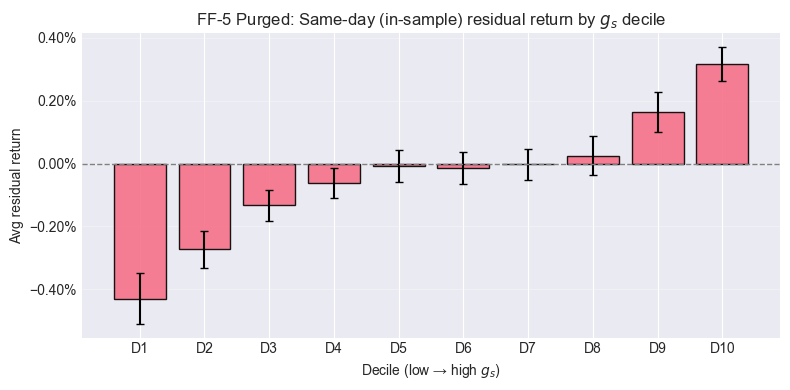

In [226]:
# Summary + plot
order = [f"D{i}" for i in range(1,11)]
dec_means = dec_ts.mean().reindex(order)
dec_se    = dec_ts.std(ddof=1).reindex(order) / np.sqrt(len(dec_ts))

# Long–short
ls = dec_ts["D10"] - dec_ts["D1"]
ls_mean = ls.mean(); ls_se = ls.std(ddof=1)/np.sqrt(len(ls))
print(dec_means.apply(lambda x: f"{x:.4%}"))
print(f"LS (D10−D1): {ls_mean:.4%} (SE {ls_se:.4%}, t≈{ls_mean/ls_se:.2f})")

# Bar plot (percent y-axis)
x = np.arange(1, 11); y = dec_means.values; yerr = 1.96 * dec_se.values
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x, y, yerr=yerr, edgecolor="black", capsize=3, alpha=0.9)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_xlabel("Decile (low → high $g_s$)")
ax.set_ylabel("Avg residual return")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=2))
ttl = "Next-day" if EVAL_NEXT_DAY else "Same-day (in-sample)"
ax.set_title(f"FF-5 Purged: {ttl} residual return by $g_s$ decile")
ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

The chart shows a clear, almost monotonic relation between sentiment-aware attention **g_s**​ and same-day FF-5–purged (abnormal) returns. Portfolios sorted into the lowest **g_s** deciles (D1–D3) earn negative residual returns (about −0.45%, −0.25%, −0.15%), while the highest deciles (D9–D10) earn positive residuals (roughly +0.15% and +0.33%). Middle deciles hover near zero. The error bars (≈95% CIs) suggest the extremes are statistically different from zero—especially D1 (clearly negative) and D10 (clearly positive). In plain terms: even after removing market, size, value, profitability, and investment effects, **days with very negative Twitter tone/attention underperform, and days with very positive tone/attention outperform—on the same day**. This is strong evidence of **contemporaneous co-movement**, not necessarily next-day predictability.

### Conclusions



**1) Same-day relation (raw returns **and** FF-5–purged):**
- **Strong monotonic pattern:** moving from **D1** (low/negative $g_s$) to **D10** (high/positive $g_s$) average returns rise steadily.  
- This holds **before and after** FF-5 risk adjustment, so it is **not** just exposure to $MKT\!-\!RF$, $SMB$, $HML$, $RMW$, or $CMA$.  
- **Interpretation:** tweets + tone co-move with prices **on the day of the news** (now-casting). High, positive attention days are up; low/negative attention days are down.

**2) Next-day relation (raw returns)**
- **Mild upward slope:** D10 > D1, but the spread is much smaller than same-day, indicating only **modest** carry-through to $t{+}1$.

**3) Next-day relation after FF-5 purge (residuals)**
- **Weak evidence:** most deciles’ 95% CIs cross zero; only the top decile shows a small positive average.  
- **Interpretation:** after removing standard risk factors, **predictive power is limited**. The effect is mainly contemporaneous, not a strong forecast of idiosyncratic returns.

---

**• Do we see a correlation between media attention and returns?**  
- **Yes, clearly for same-day:** higher $g_s \Rightarrow$ higher return (and vice-versa), even after FF-5.  
- **Next-day:** a small positive relation exists in raw returns, but largely **dissipates** once FF-5 is removed.

**• Is Twitter attention a good factor?**  
- **Attention alone ($g$):** not compelling.  
- **Sentiment-aware attention ($g_s$):**
  - Excellent **contemporaneous** signal (monitoring/now-casting).  
  - As a **predictive factor**, only **weak** evidence: the $t{+}1$ D10–D1 spread is small and not robust after FF-5.

---

What would make the case factor-grade (suggested by ChatGPT, would be great if we could discuss in class, since it is not entirely clear to us)

- Report **D10–D1** averages and $t$-stats for $t{+}1$ (raw and FF-5-purged). Let $R^{LS}_{t} = R_{10,t} - R_{1,t}$ and test $\bar R^{LS} / \big(\mathrm{sd}(R^{LS})/\sqrt{T}\big)$.  
- **Subperiod** and **sector-neutral** checks.  
- **Value-weighted** portfolios and transaction-cost analysis.  
- (Optional) purge with **rolling betas** to ensure results aren’t an artifact of static loadings.